<a href="https://colab.research.google.com/github/Rayhan-labib7/FInal_Year_Research_Project/blob/main/project_21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from IPython.display import Image
import shutil
import os
from sklearn.model_selection import train_test_split

In [ ]:

!git clone https://github.com/ultralytics/yolov5
%cd yolov5/
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 16383, done.
remote: Counting objects: 100% (277/277), done.
remote: Compressing objects: 100% (206/206), done.
remote: Total 16383 (delta 138), reused 153 (delta 71), pack-reused 16106
Receiving objects: 100% (16383/16383), 15.09 MiB | 11.58 MiB/s, done.
Resolving deltas: 100% (11176/11176), done.
/content/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.4/196.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 23.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 702.8/702.8 kB 38.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: Pillow 9.4.0
    Uninstalling Pillow-9.4.0:
      Successfully uninstalled Pillow-9.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following d

In [ ]:

crs_path = "/content/drive/MyDrive/Road_Sign_DataSet/ts/ts"
train_path = "/content/dataset/images/train"
val_path = "/content/dataset/images/val"

In [ ]:

imgs = [filename for filename in os.listdir(crs_path) if not filename.endswith(".txt")]
xmls = [filename[:-4] + ".txt" for filename in imgs]

In [ ]:

train_imgs, val_imgs = train_test_split(imgs, test_size=0.2, random_state=42)
train_xmls = [filename[:-4] + ".txt" for filename in train_imgs]
val_xmls = [filename[:-4] + ".txt" for filename in val_imgs]

In [ ]:

def copy_files(src_paths, dest_path):
    for filename in src_paths:
        shutil.copy(os.path.join(crs_path, filename), os.path.join(dest_path, filename))

In [ ]:

for path in [train_path, val_path]:
    image_path = os.path.join(path, "images")
    label_path = os.path.join(path, "labels")
    os.makedirs(image_path, exist_ok=True)
    os.makedirs(label_path, exist_ok=True)

    cache_path = os.path.join(label_path, "train.cache.npy")
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    open(cache_path, 'w').close()

In [ ]:

copy_files(train_imgs, os.path.join(train_path, "images"))
copy_files(train_xmls, os.path.join(train_path, "labels"))

In [ ]:

copy_files(val_imgs, os.path.join(val_path, "images"))
copy_files(val_xmls, os.path.join(val_path, "labels"))

In [ ]:

!pip install googledrivedownloader
from google_drive_downloader import GoogleDriveDownloader as gdd
gdd.download_file_from_google_drive(file_id='1KtlDXpLCfqoklUTdrnVASNbxL_AK9qnx',
                                    dest_path='/content/dataset/dataset.yaml')

In [ ]:

with open(r'/content/dataset/dataset.yaml', 'r') as file:
    lines = file.readlines()
    print(lines)

['train: /kaggle/working/dataset/images/train\n', 'val: /kaggle/working/dataset/images/val\n', '\n', 'nc: 4\n', "names: ['speed limit','yield','mandatory','other']"]


In [ ]:

!python train.py --img 416 --batch 16 --epochs 30 --data /content/dataset/dataset.yaml --weights yolov5s.pt --cache --workers 2

2024-01-24 05:13:04.647216: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-01-24 05:13:04.647268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-01-24 05:13:04.649134: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
train: weights=yolov5s.pt, cfg=, data=/content/dataset/dataset.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=30, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, sing

In [ ]:
# Perform object detection on a sample image
!python detect.py --source /content/dataset/images/val/images/00004.jpg --weights runs/train/exp/weights/best.pt

detect: weights=['runs/train/exp/weights/best.pt'], source=/content/dataset/images/val/images/00004.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-278-g050c72c Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
image 1/1 /content/dataset/images/val/images/00004.jpg: 384x640 1 speed limit, 1 mandatory, 47.8ms
Speed: 0.5ms pre-process, 47.8ms inference, 533.9ms NMS per image at shape (1, 3, 640, 640)
Results saved to runs/detect/exp


In [ ]:
# Perform object detection on a sample image
!python detect.py --source /content/dataset/images/val/images/00004.jpg --weights runs/train/exp/weights/best.pt

detect: weights=['runs/train/exp/weights/best.pt'], source=/content/dataset/images/val/images/00004.jpg, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-278-g050c72c Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Traceback (most recent call last):
  File "/content/yolov5/detect.py", line 309, in <module>
    main(opt)
  File "/content/yolov5/detect.py", line 304, in main
    run(**vars(opt))
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/_contextlib.py", line 115, in decorate_context
    return func(*args, **kwargs)
  File "/content/yolov5/detect.py", line 115, in run
    model = DetectMu

In [ ]:
from IPython.display import Image, display

In [ ]:
image_path = "/content/yolov5/runs/train/exp/F1_curve.png"

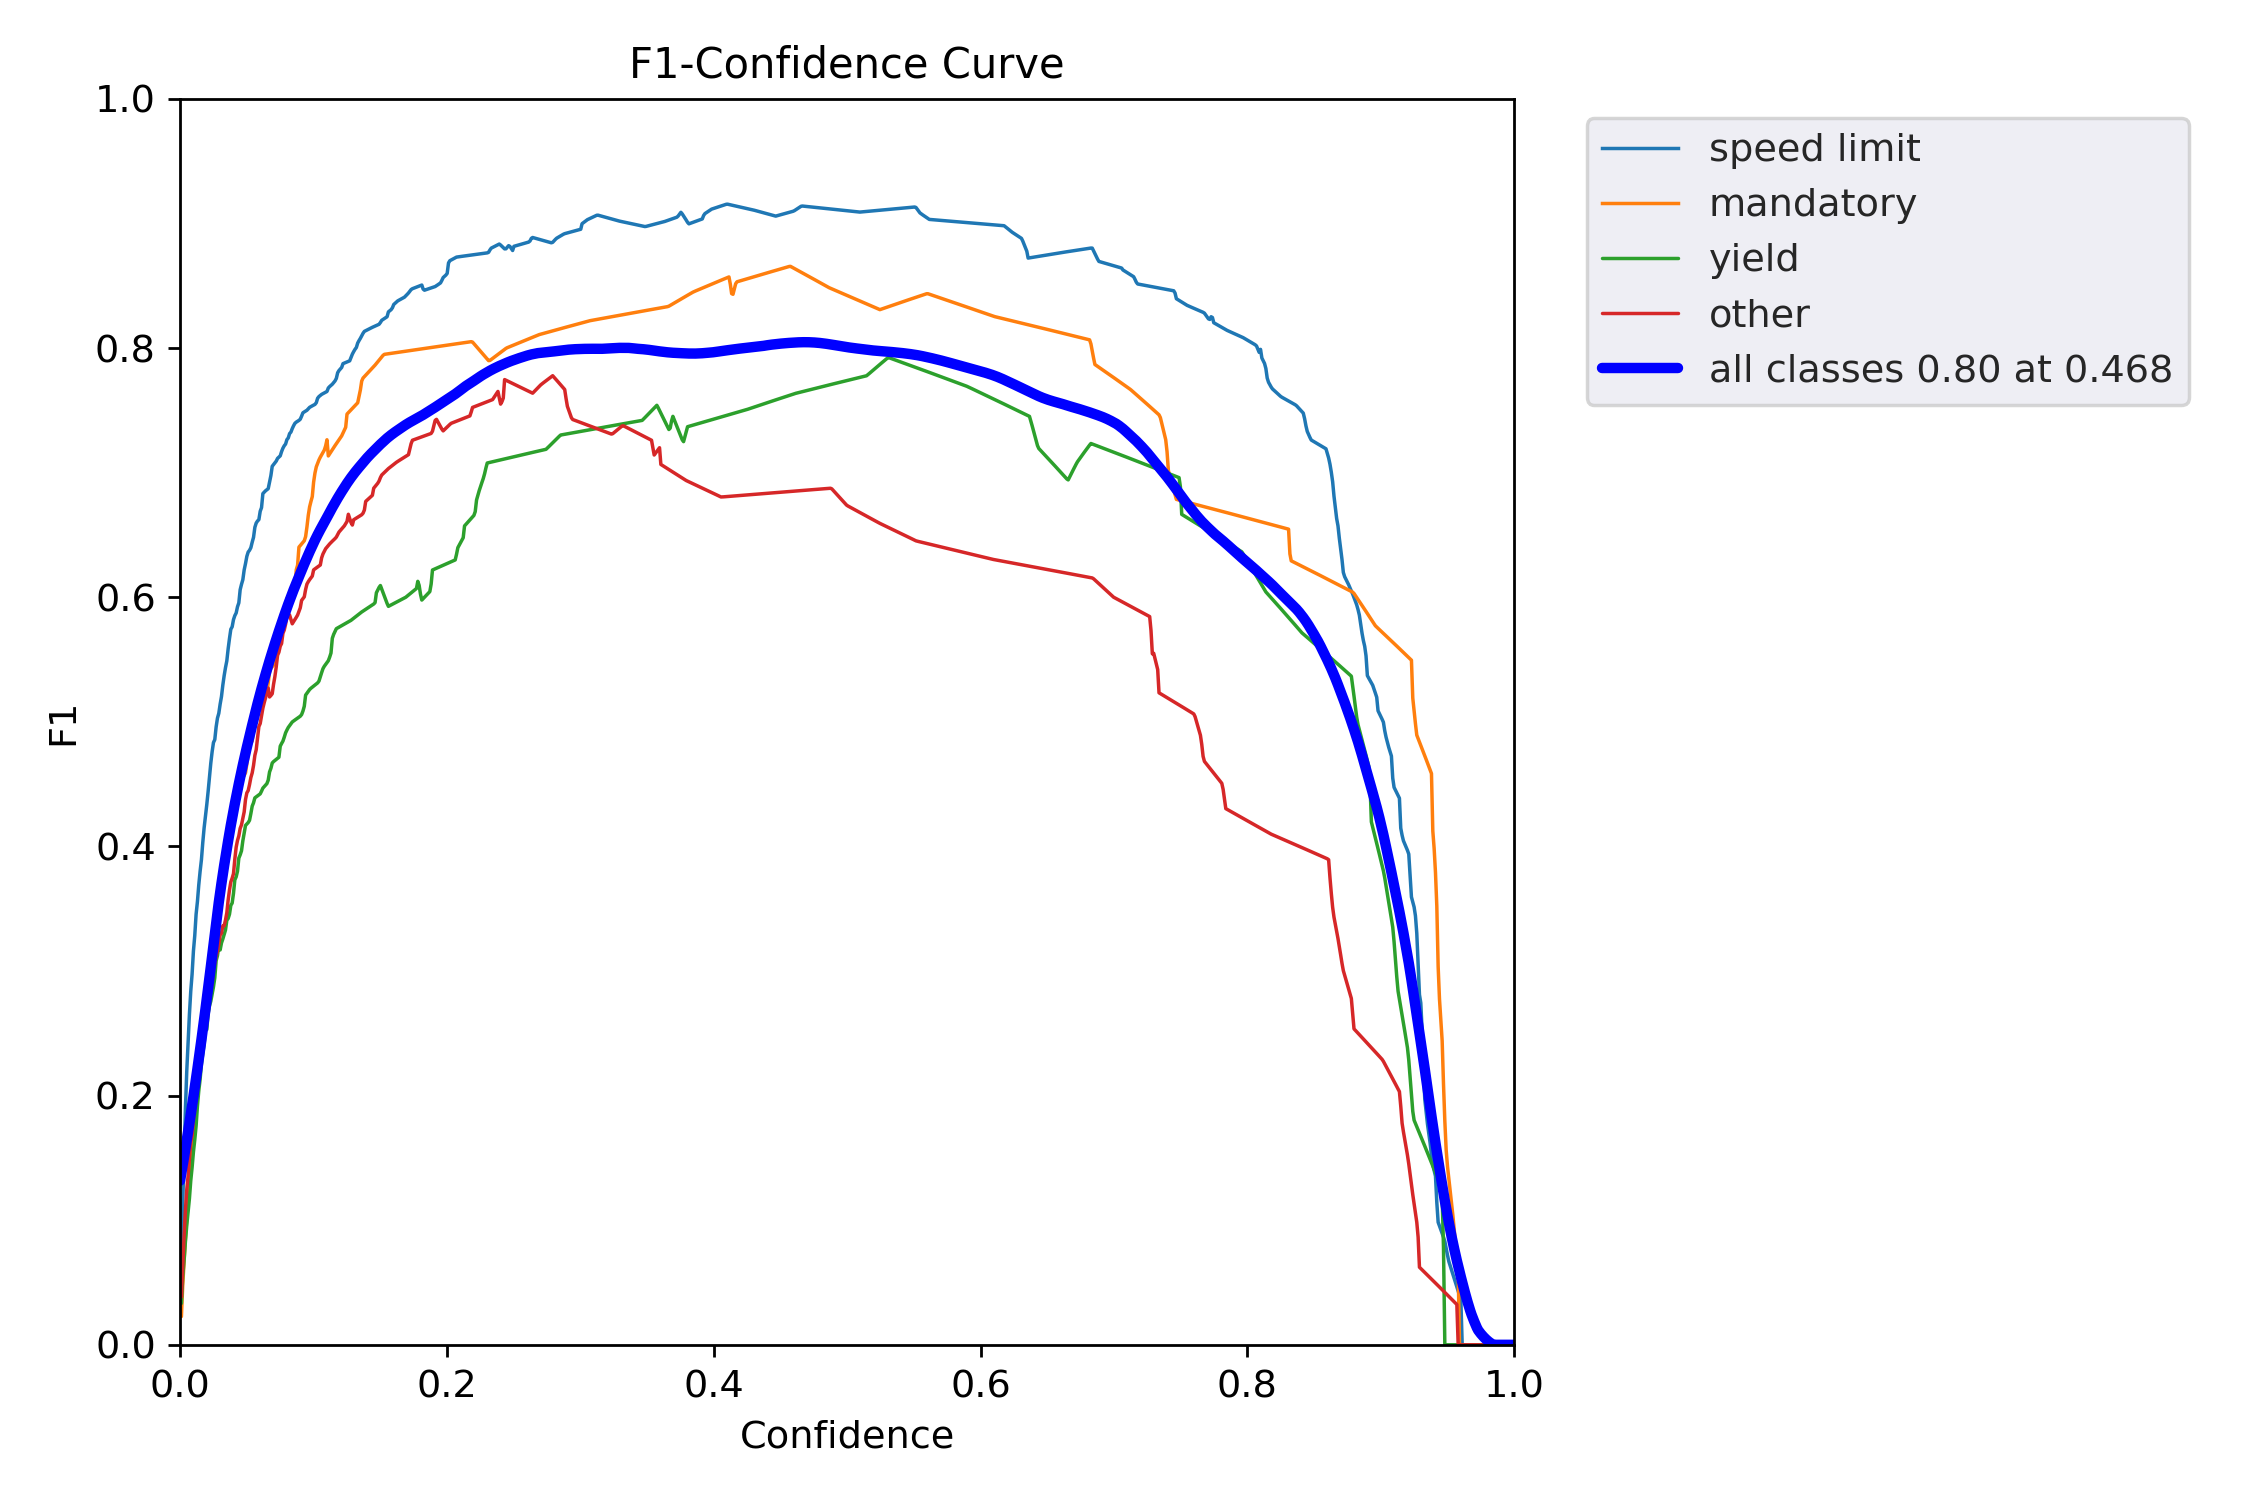

In [ ]:
display(Image(filename=image_path))

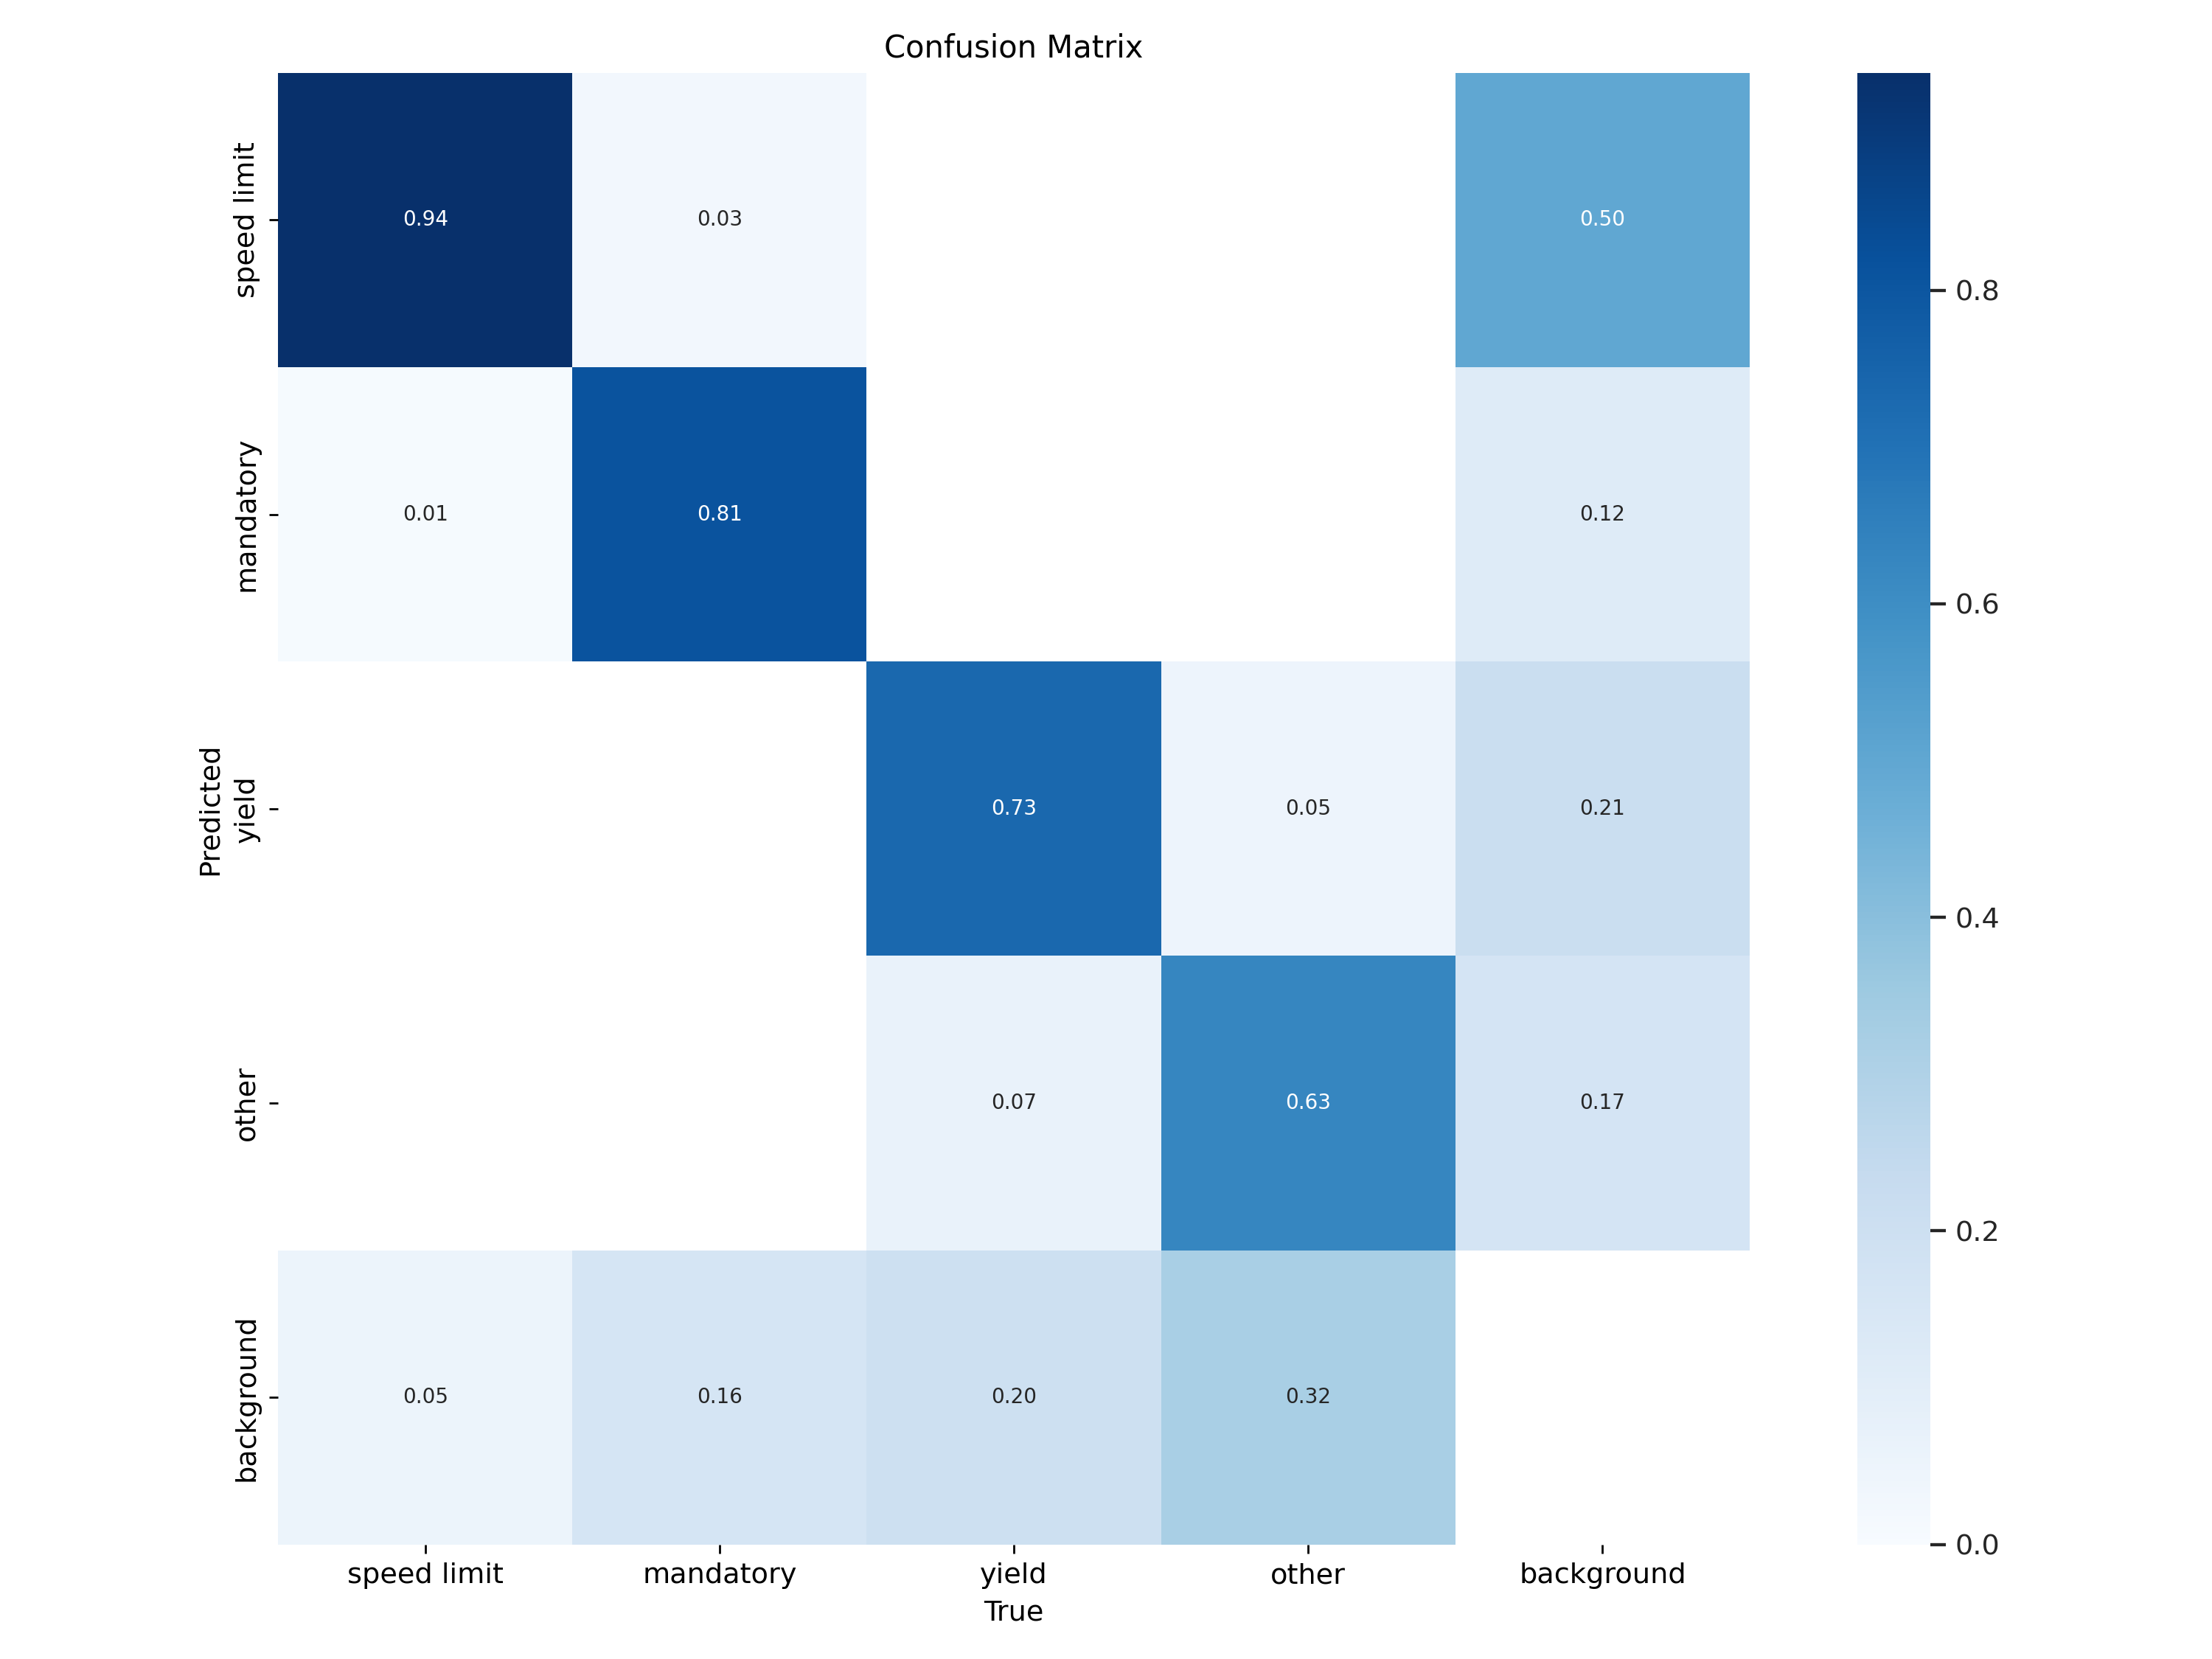

In [ ]:
image_path = "/content/yolov5/runs/train/exp/confusion_matrix.png"
display(Image(filename=image_path))

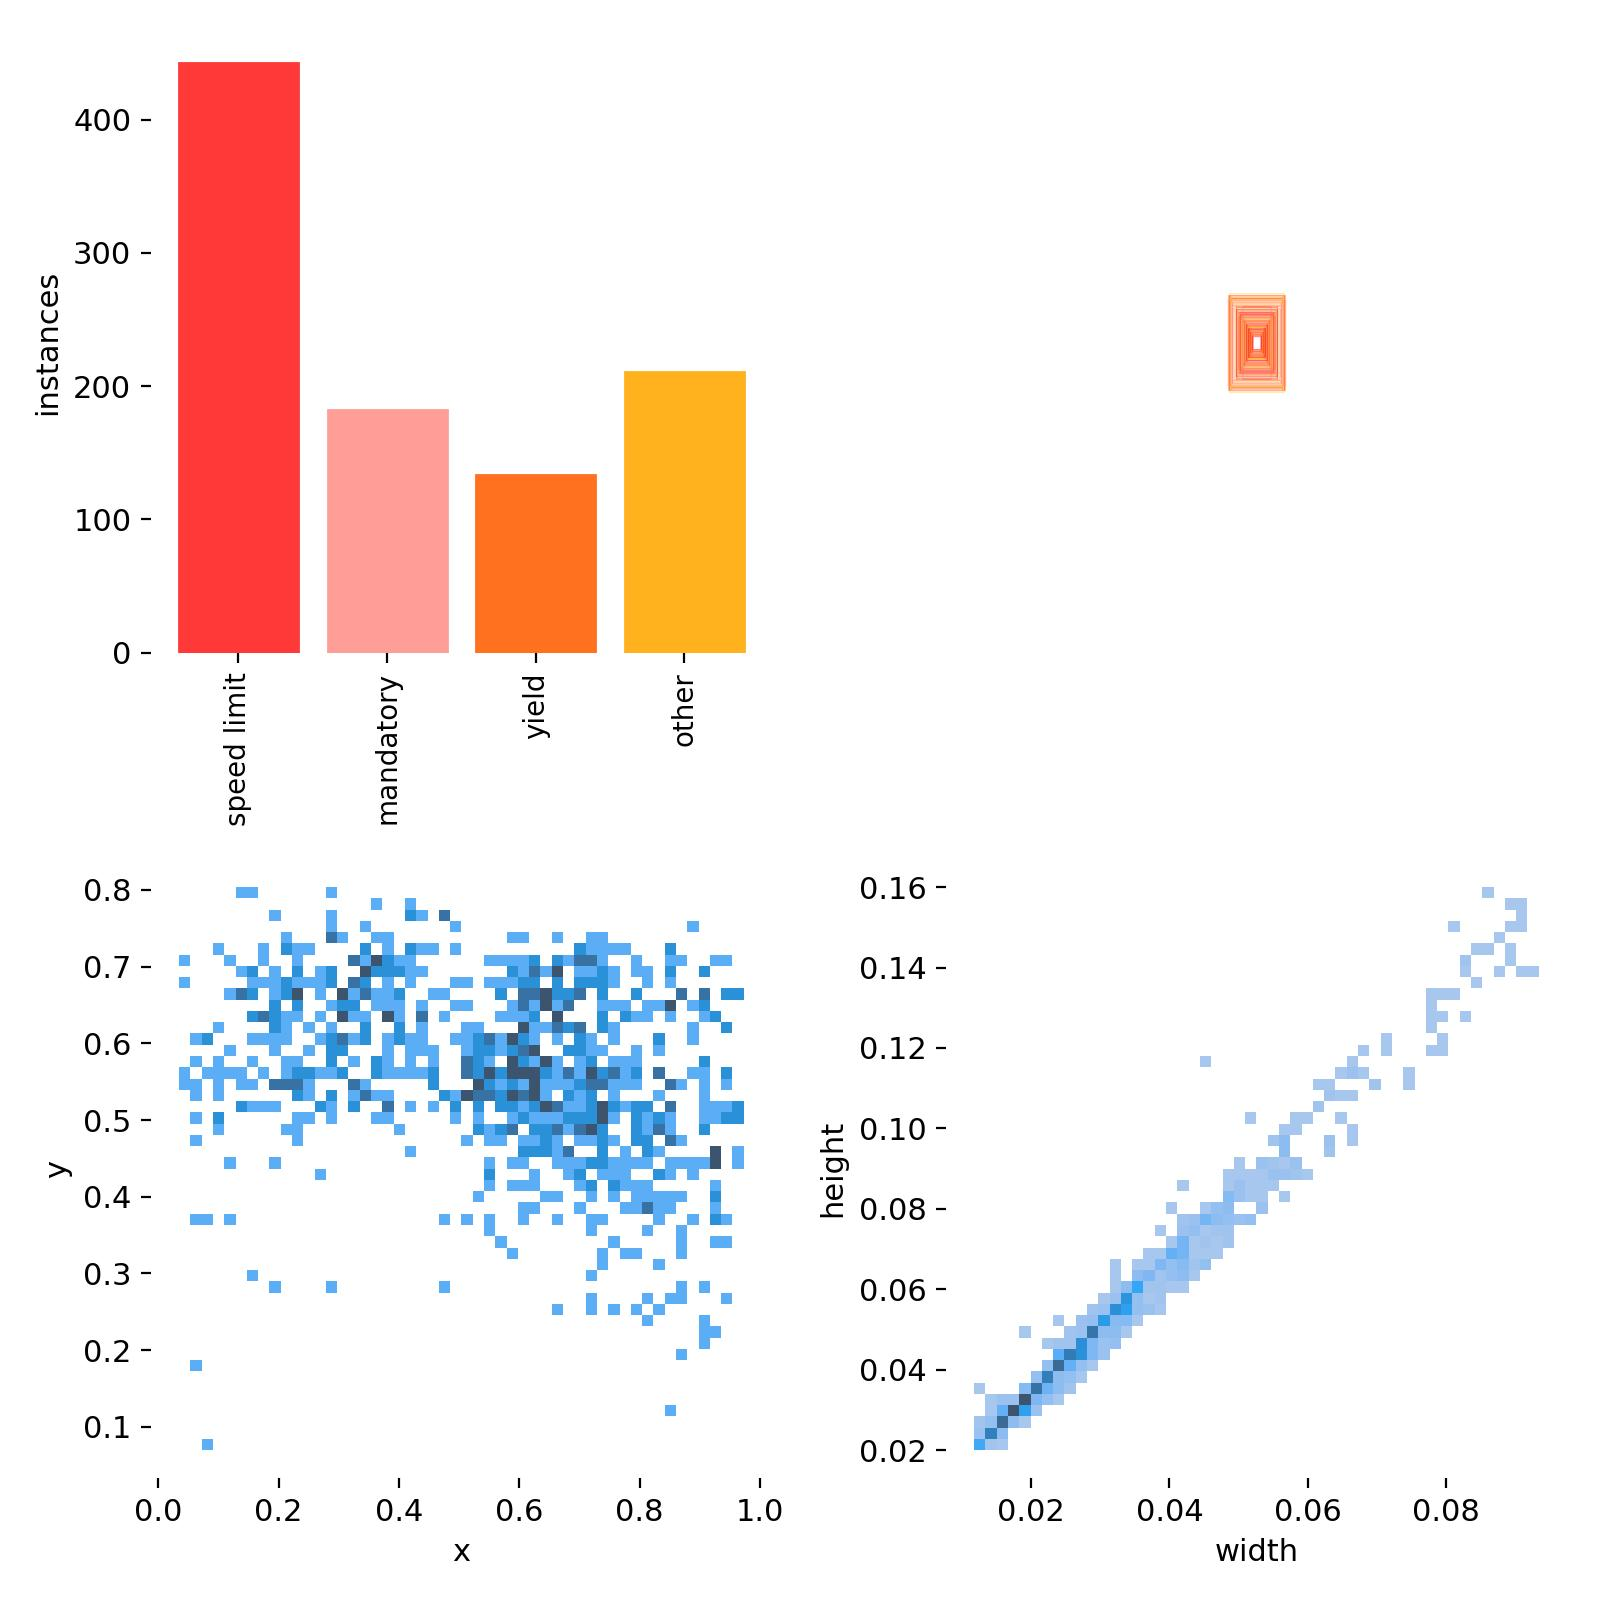

In [ ]:
image_path = "/content/yolov5/runs/train/exp/labels.jpg"
display(Image(filename=image_path))

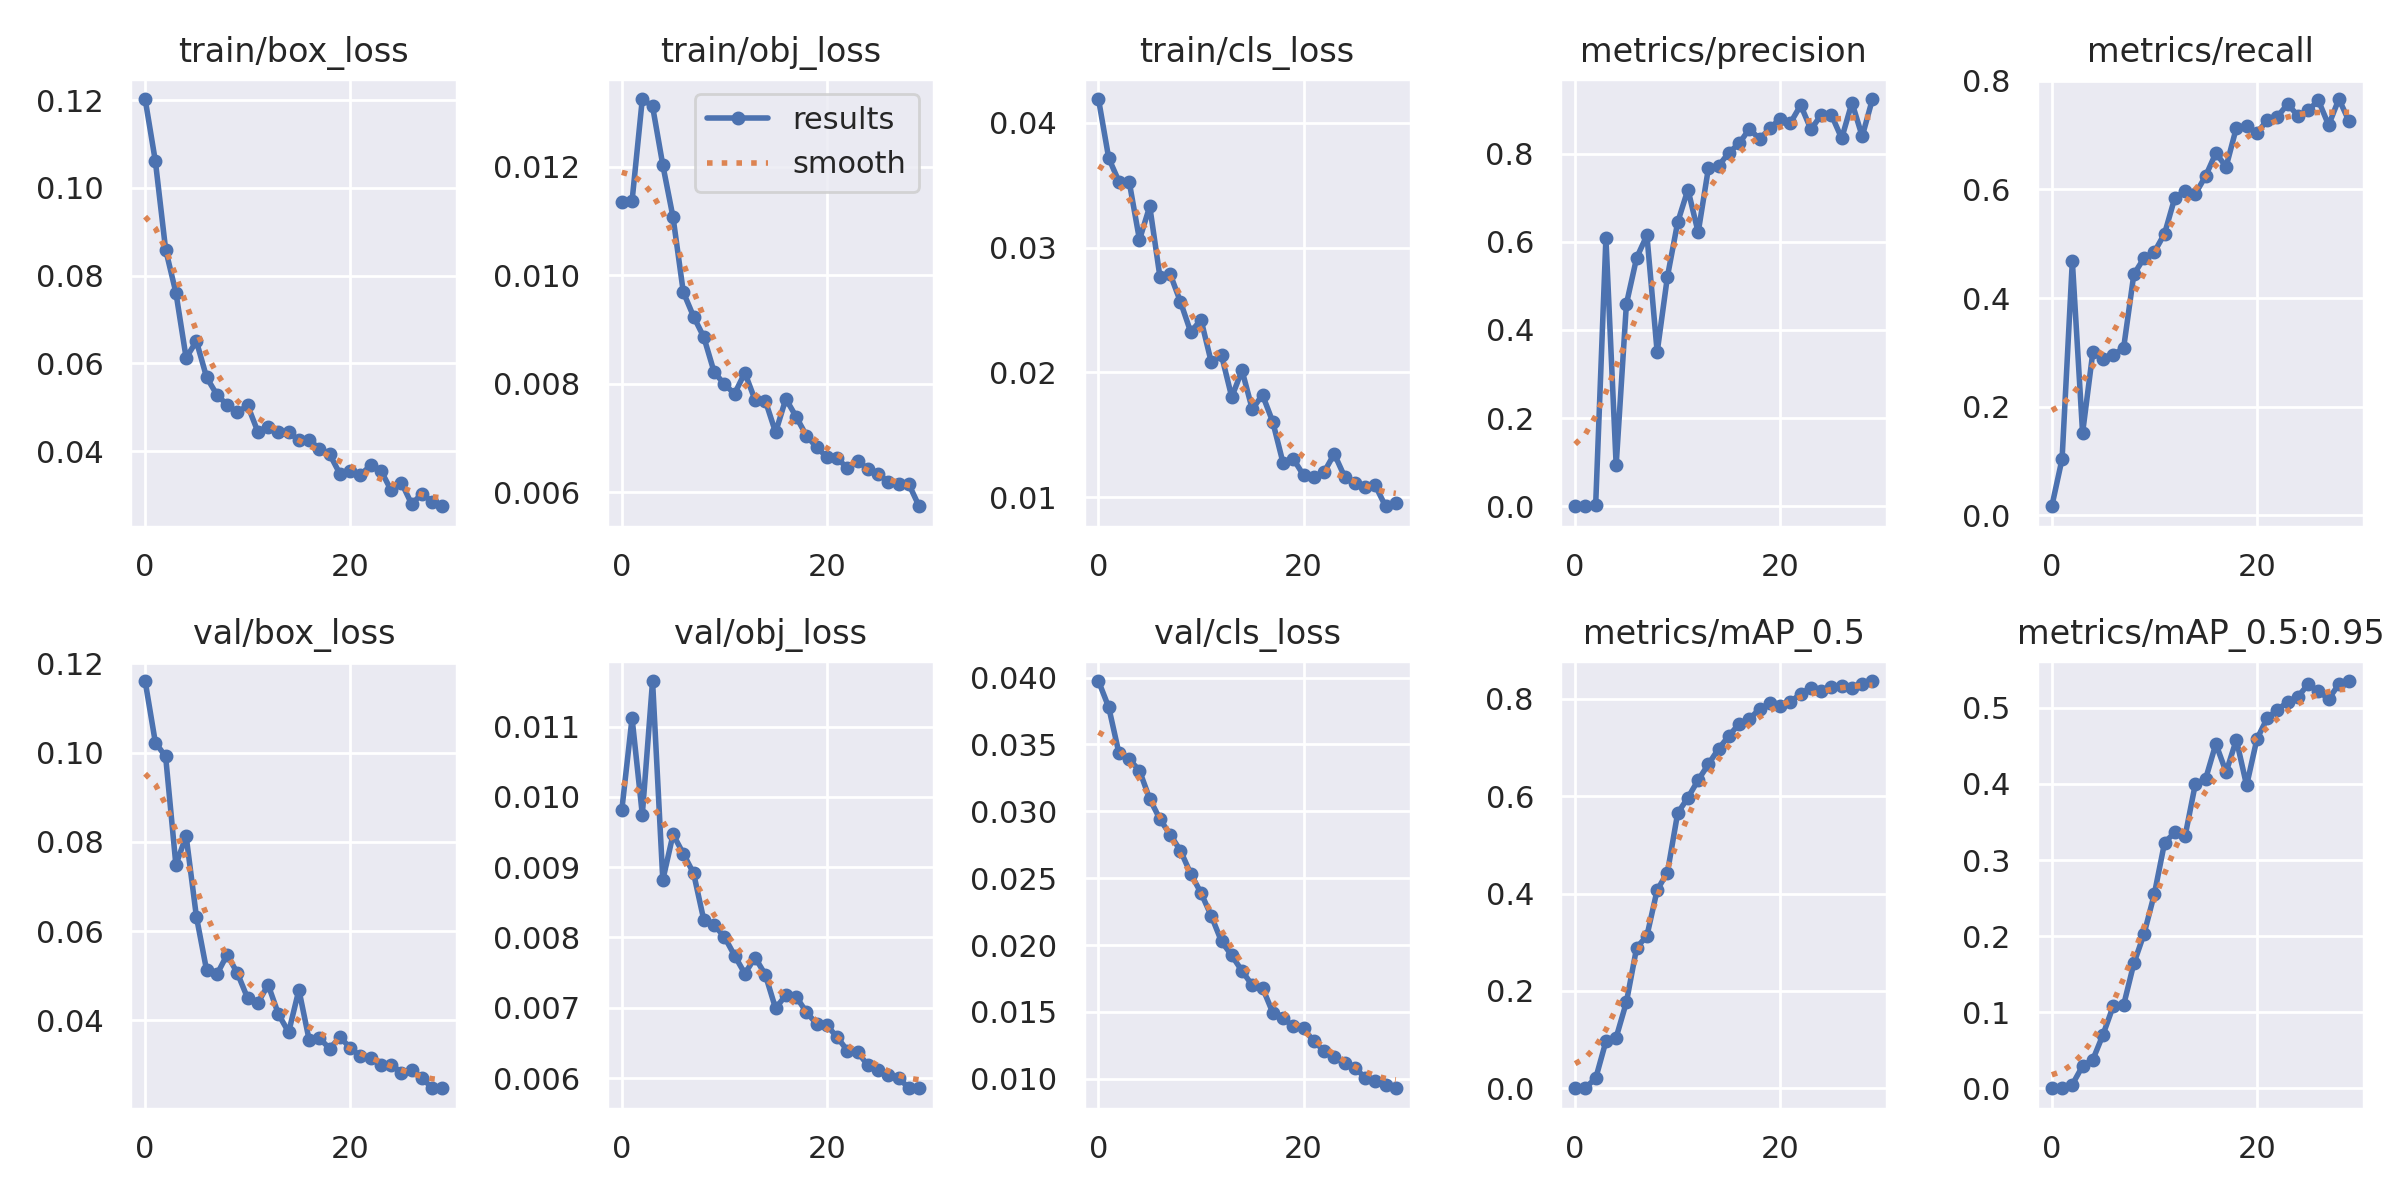

In [ ]:
image_path = "/content/yolov5/runs/train/exp/results.png"
display(Image(filename=image_path))

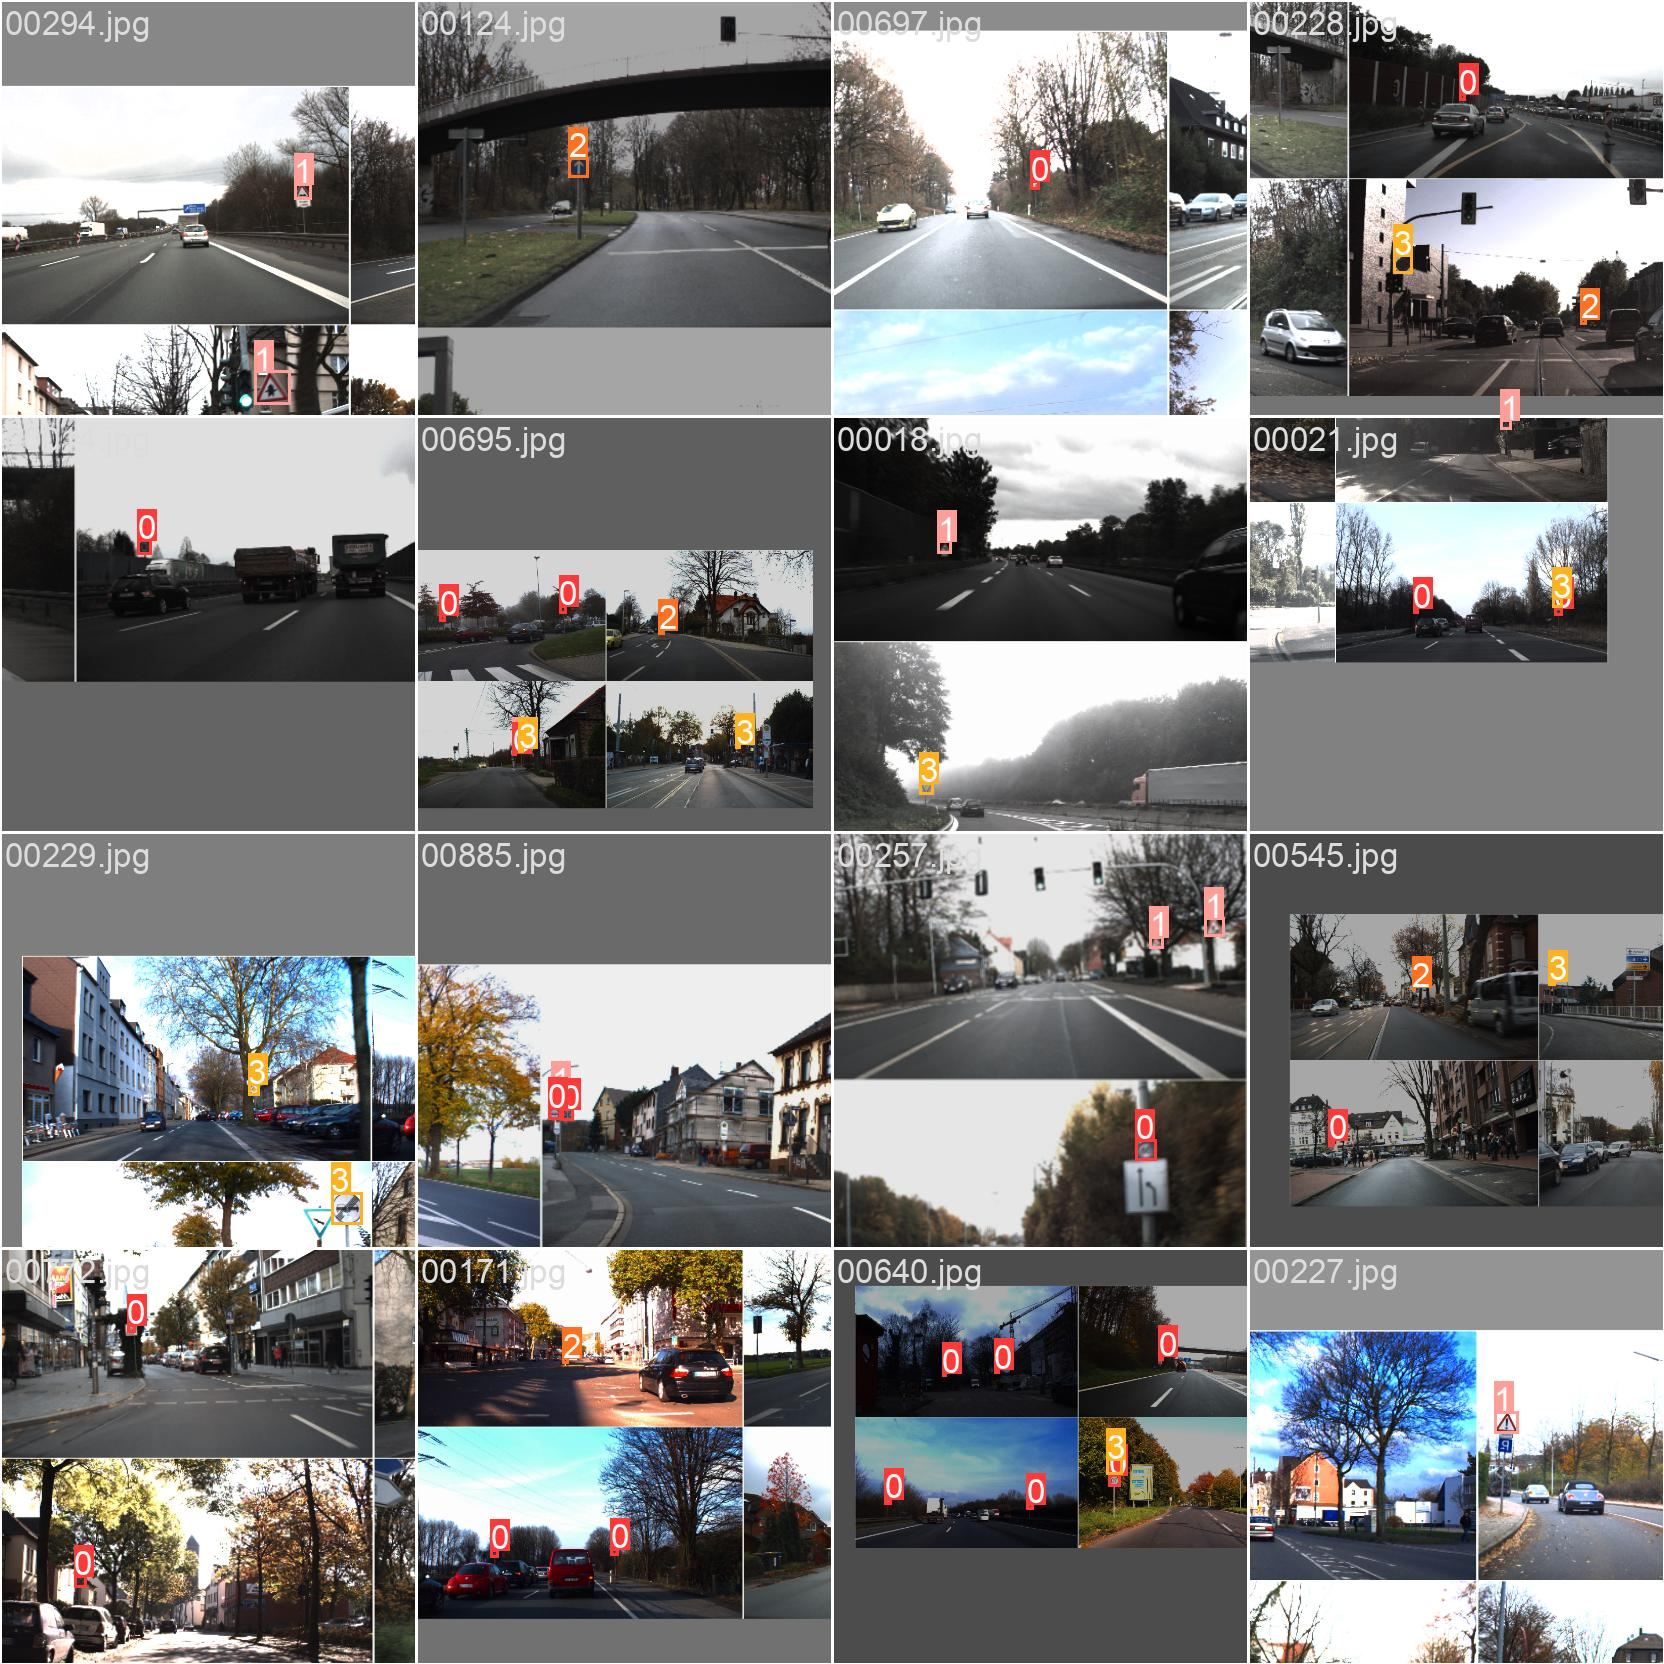

In [ ]:
image_path = "/content/yolov5/runs/train/exp/train_batch0.jpg"
display(Image(filename=image_path))

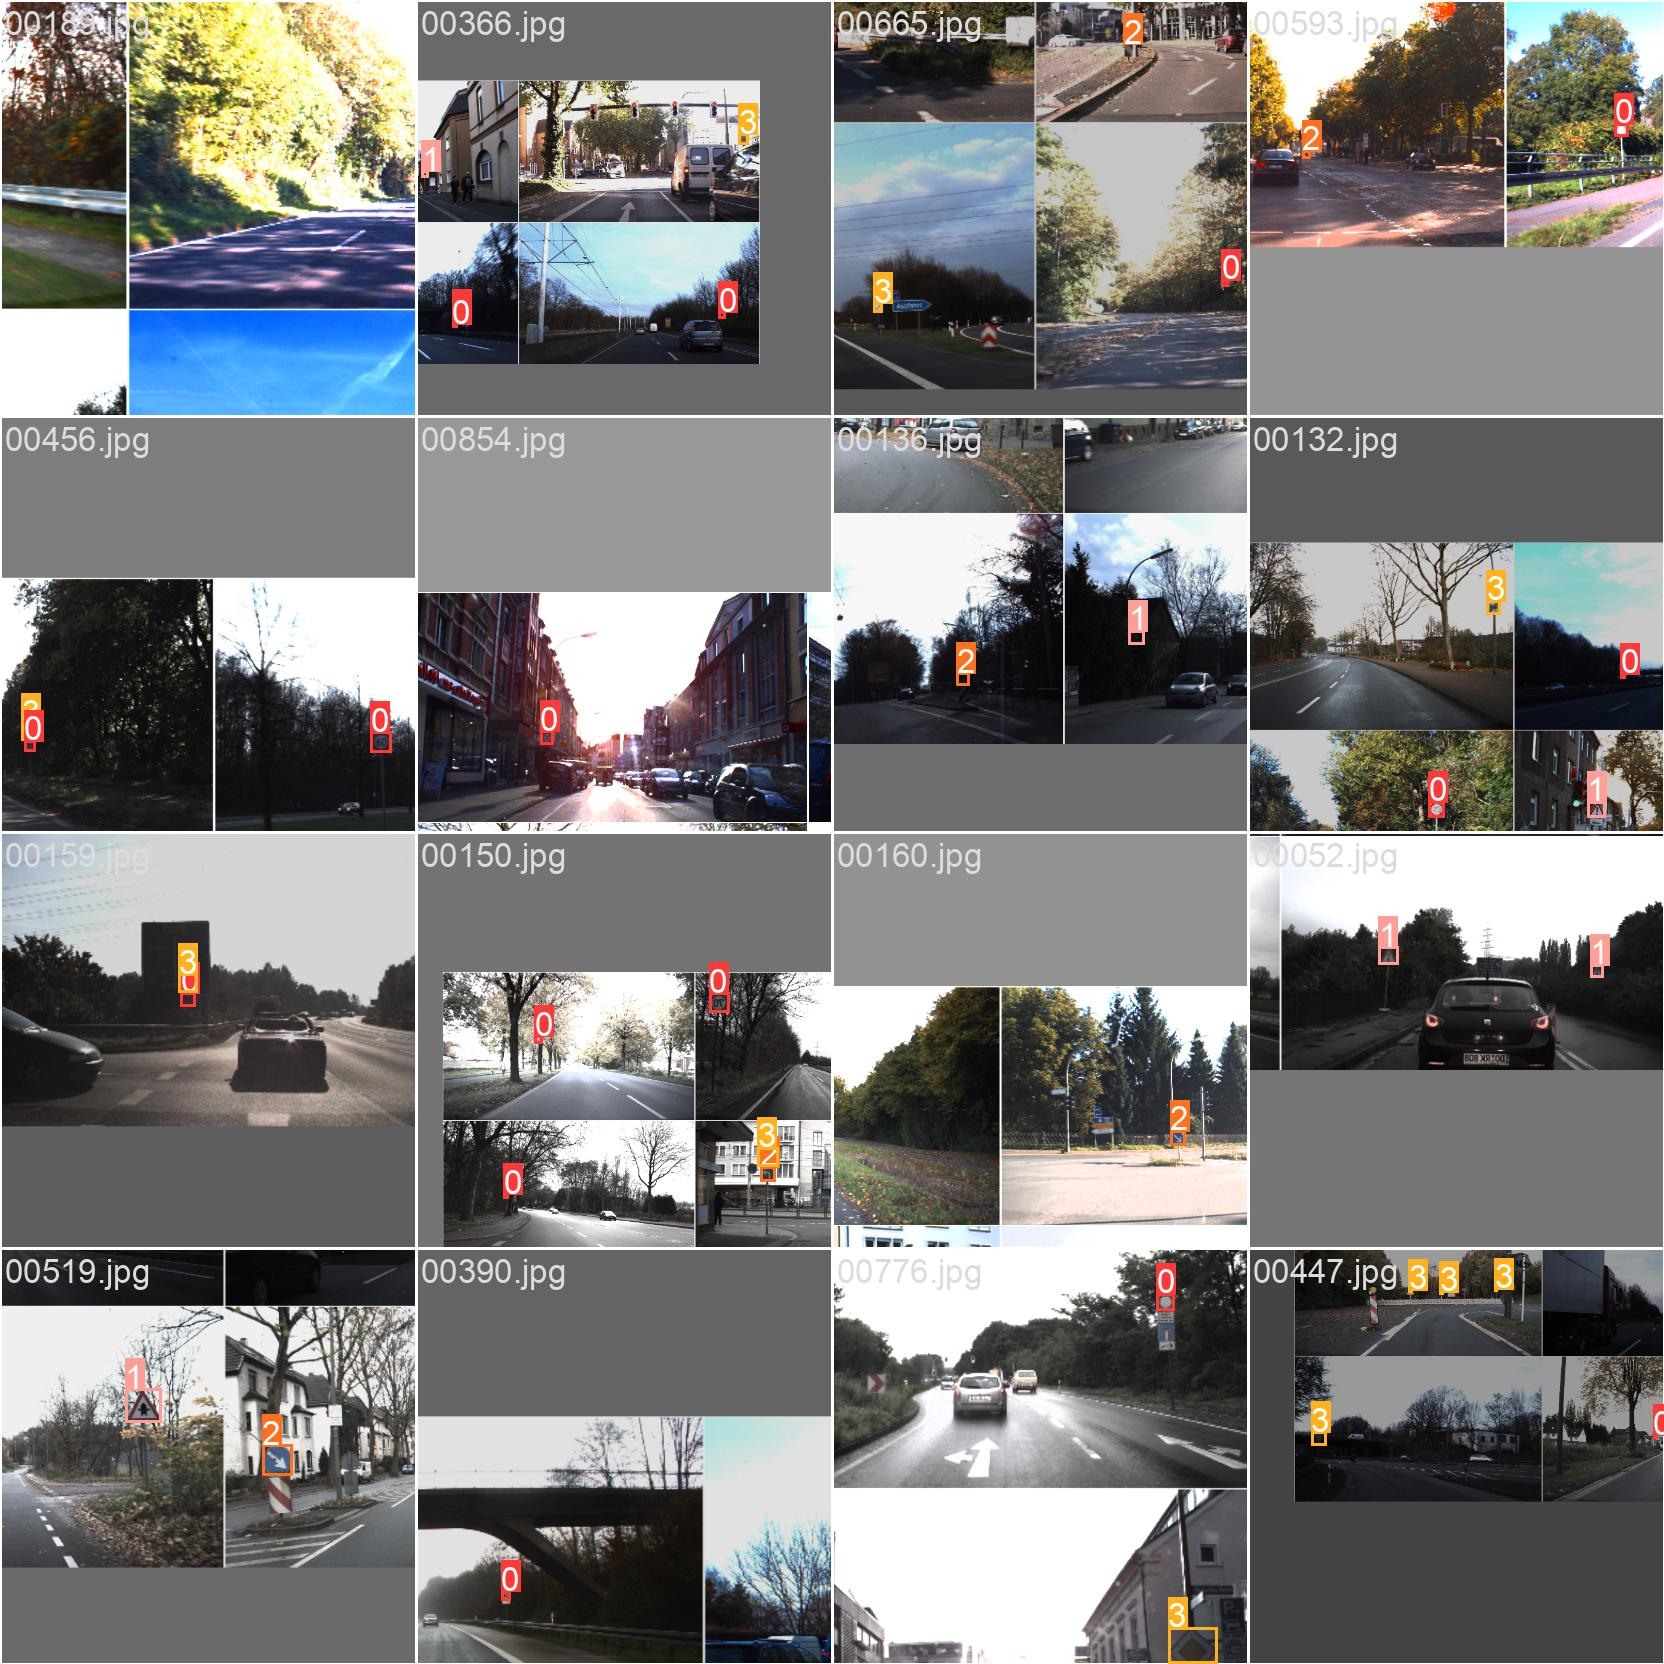

In [ ]:
image_path = "/content/yolov5/runs/train/exp/train_batch2.jpg"
display(Image(filename=image_path))

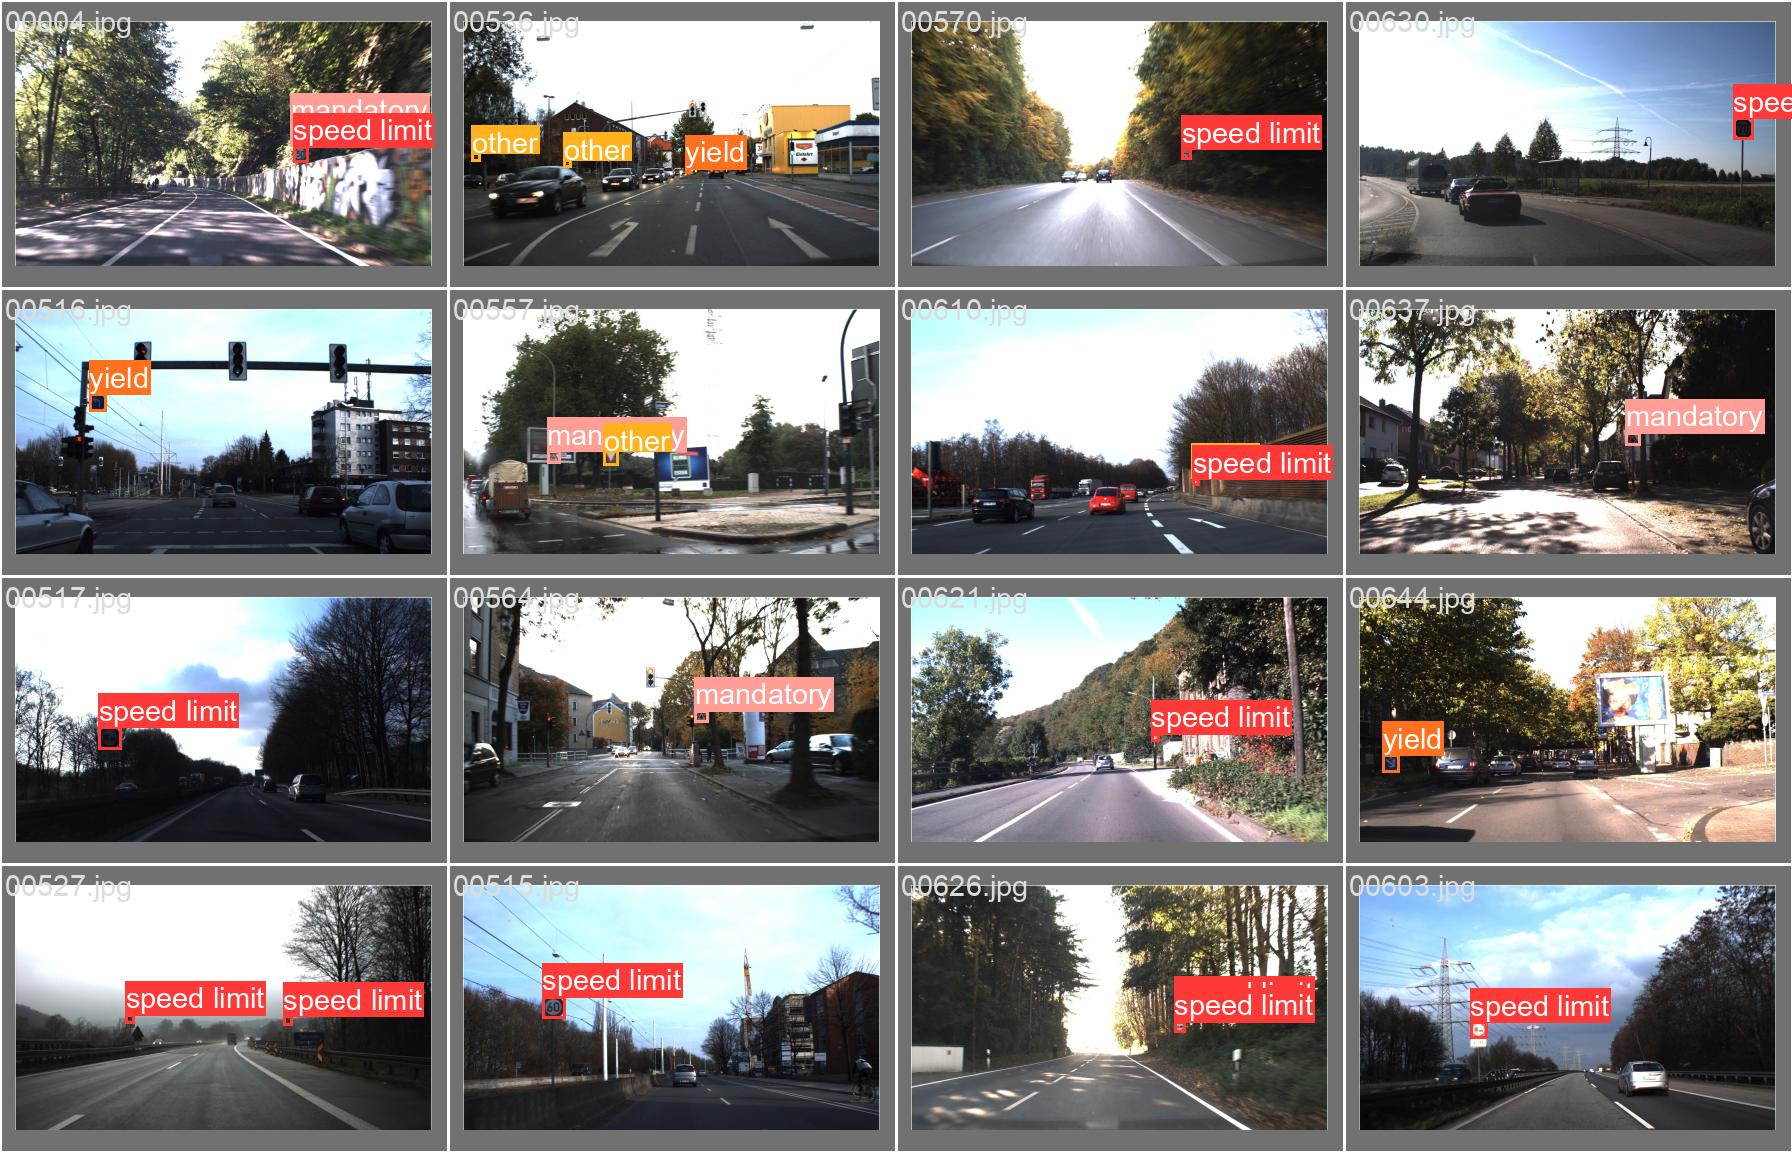

In [ ]:
image_path = "/content/yolov5/runs/train/exp/val_batch0_labels.jpg"
display(Image(filename=image_path))

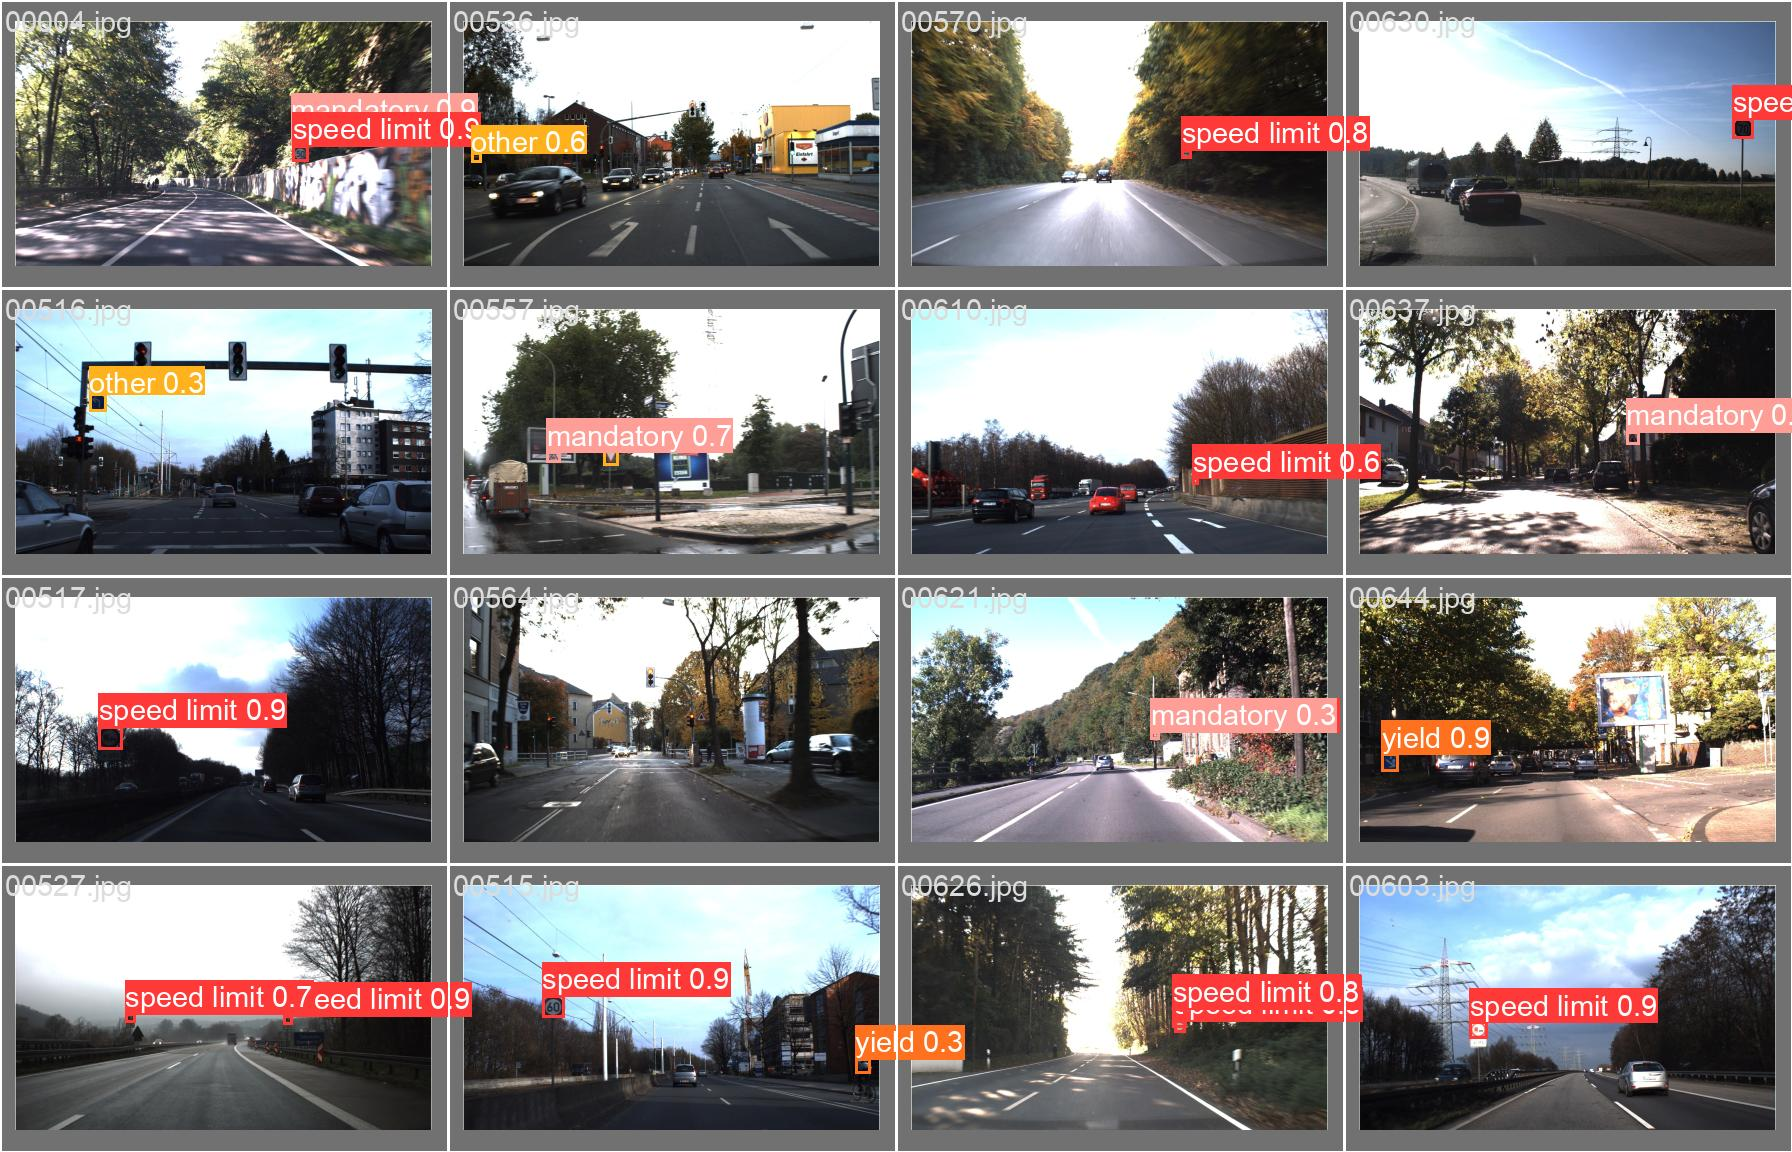

In [ ]:
image_path = "/content/yolov5/runs/train/exp/val_batch0_pred.jpg"
display(Image(filename=image_path))

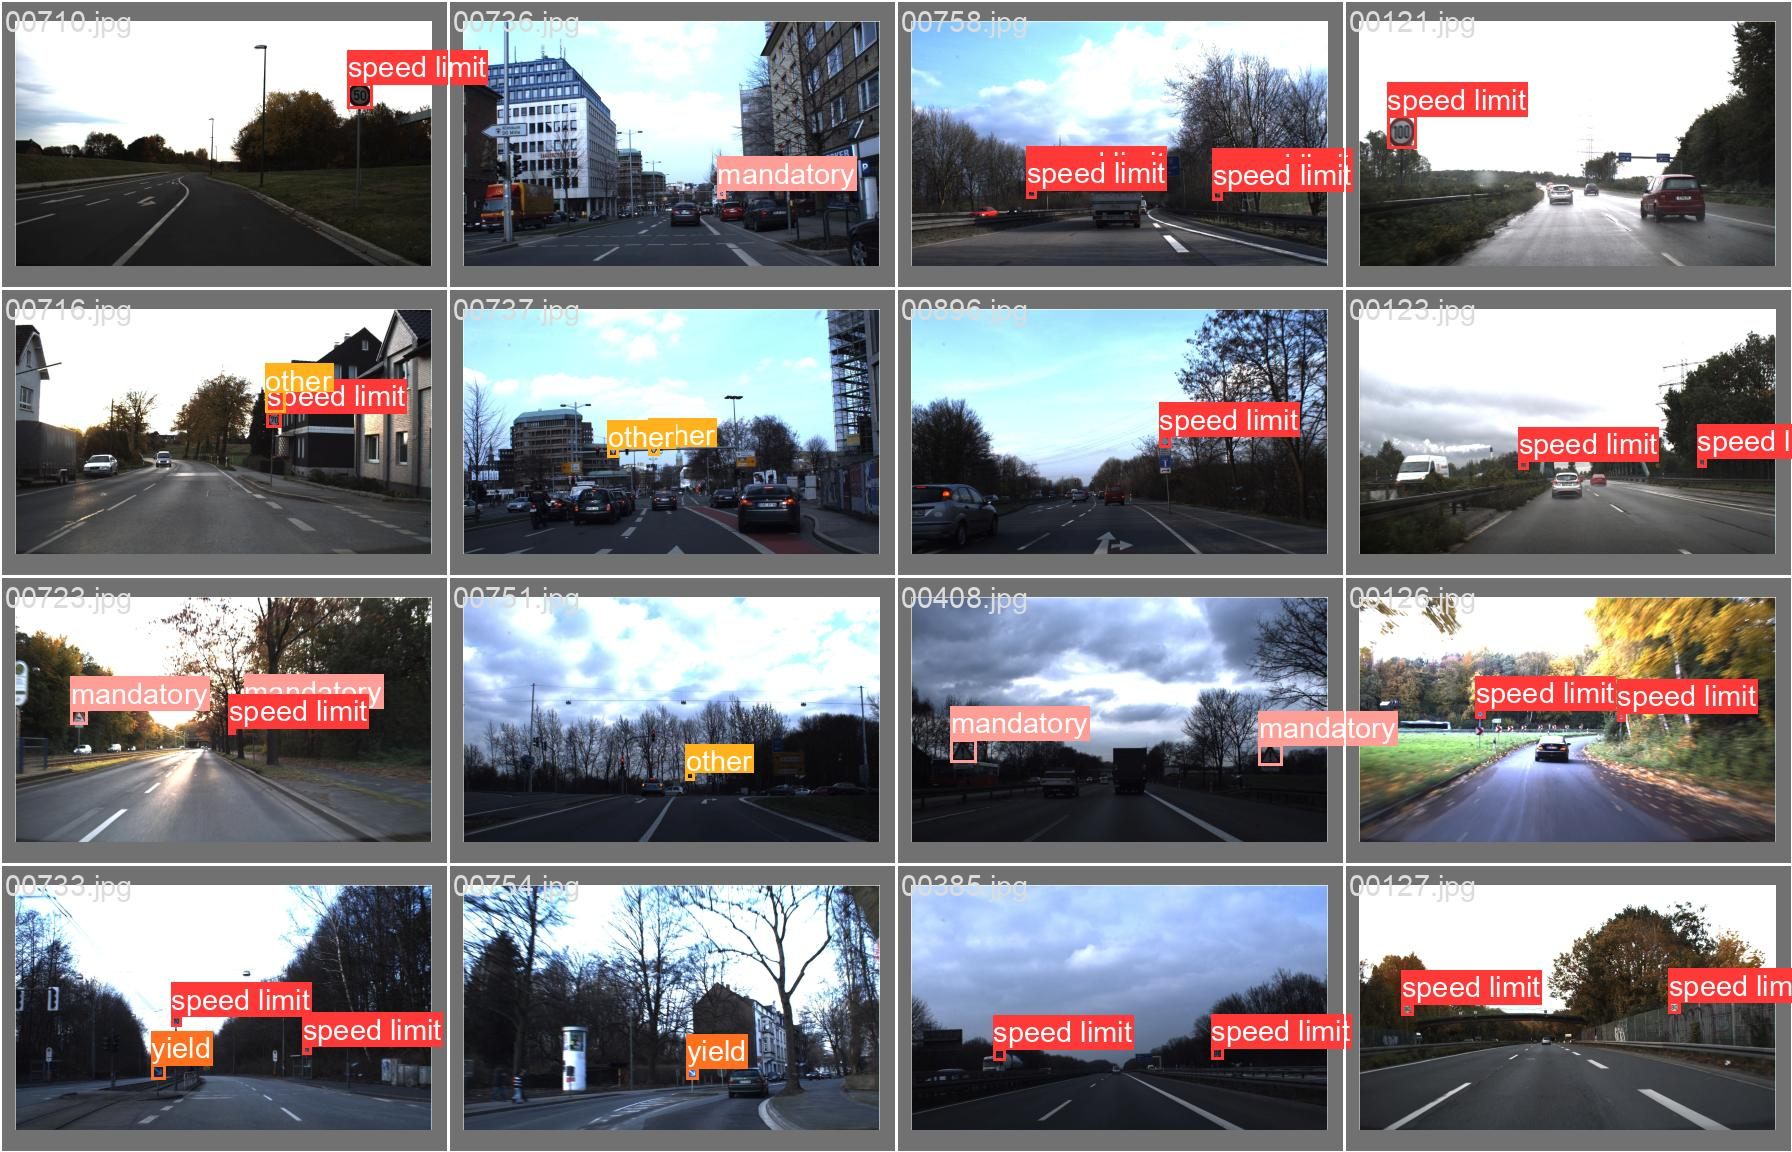

In [ ]:
image_path = "/content/yolov5/runs/train/exp/val_batch2_labels.jpg"
display(Image(filename=image_path))

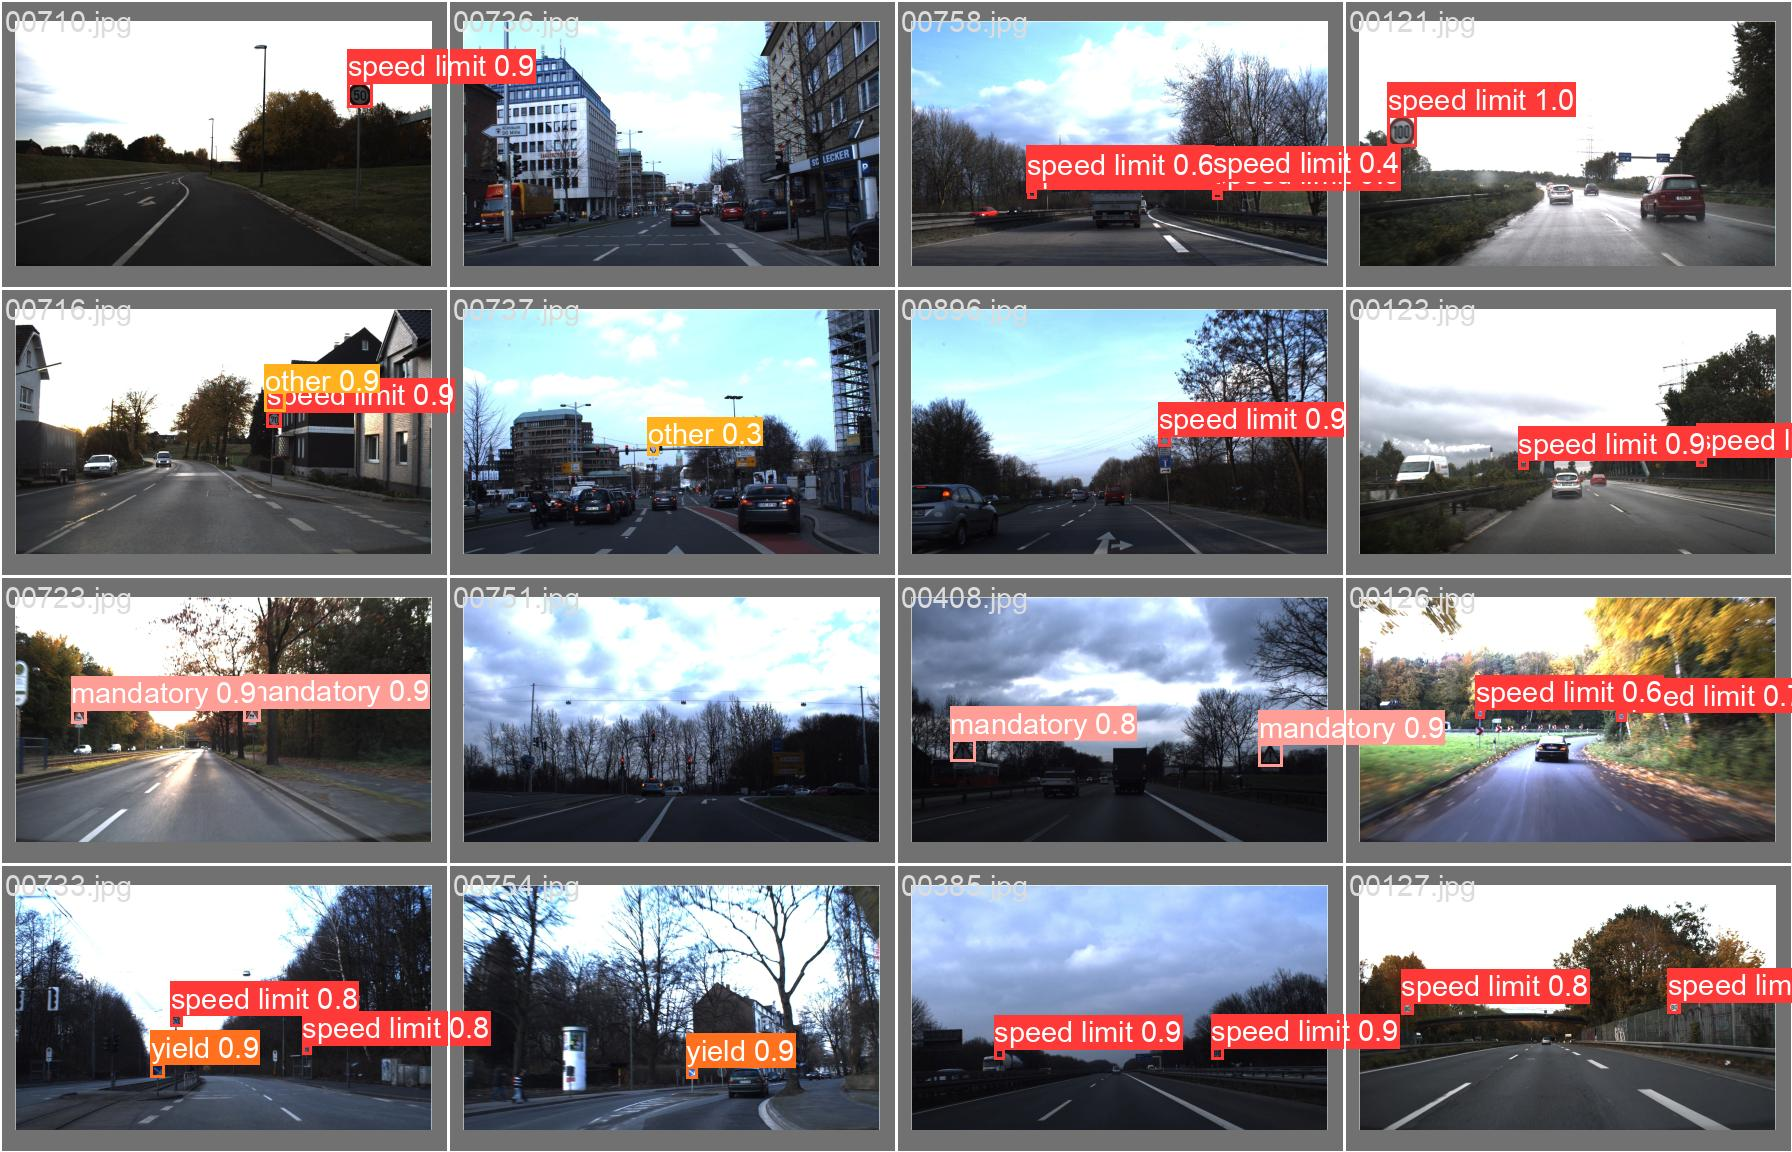

In [ ]:
image_path = "/content/yolov5/runs/train/exp/val_batch2_pred.jpg"
display(Image(filename=image_path))

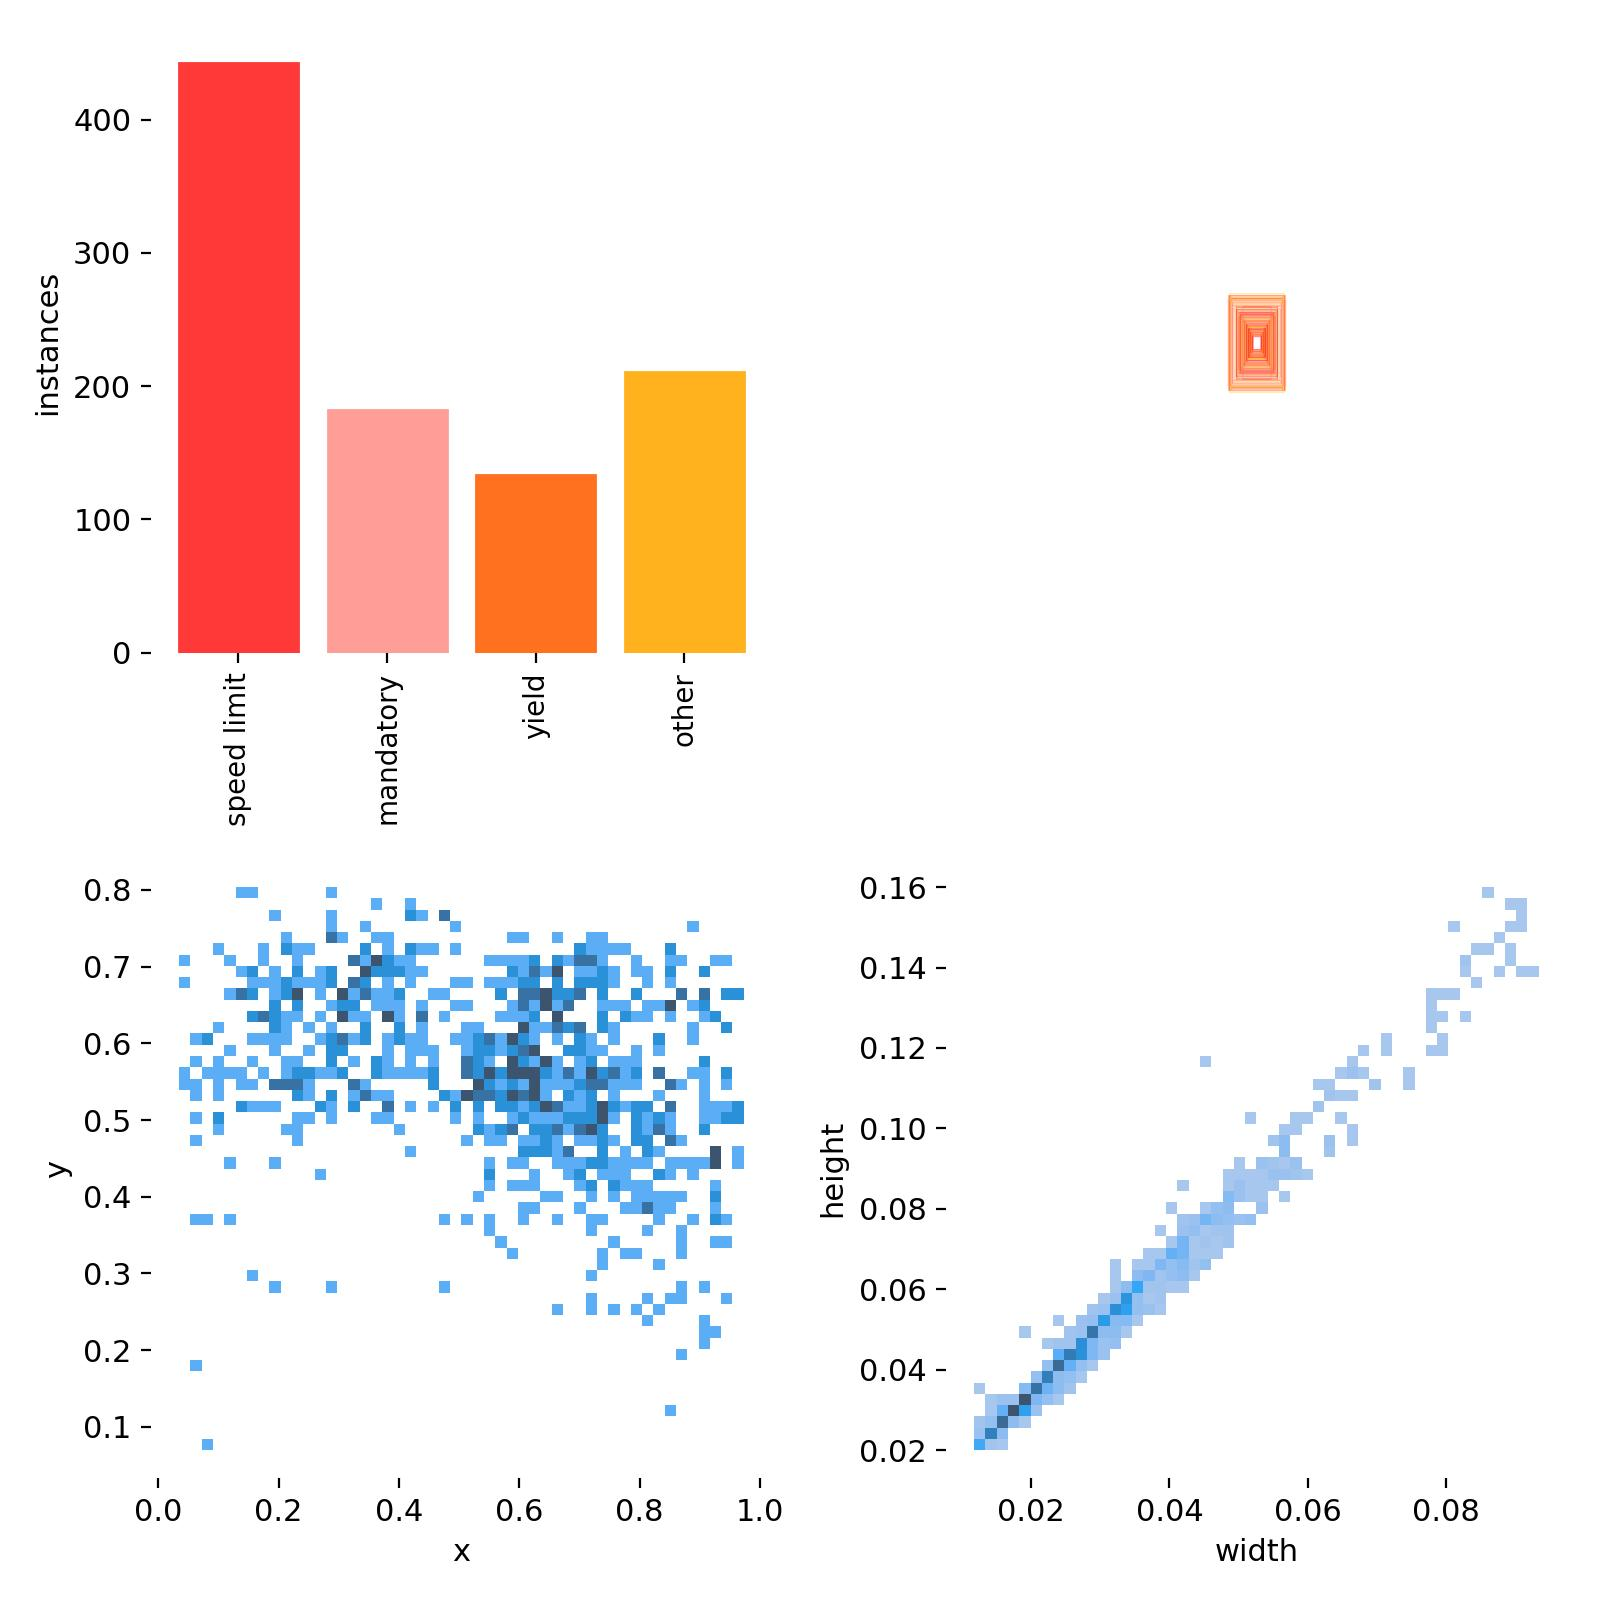

In [ ]:
image_path = "/content/yolov5/runs/train/exp/labels.jpg"
display(Image(filename=image_path))

In [ ]:
# List detection results
!ls ./runs/detect

ls: cannot access './runs/detect': No such file or directory


In [ ]:
!python detect.py --source /content/drive/MyDrive/Road_Sign_DataSet/Road_sign_test.mp4 --weights /content/yolov5/runs/train/exp/weights/best.pt


detect: weights=['/content/yolov5/runs/train/exp/weights/best.pt'], source=/content/drive/MyDrive/Road_Sign_DataSet/Road_sign_test.mp4, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-278-g050c72c Python-3.10.12 torch-2.1.0+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
Model summary: 157 layers, 7020913 parameters, 0 gradients, 15.8 GFLOPs
WARNING ⚠️ NMS time limit 0.550s exceeded
video 1/1 (1/1053) /content/drive/MyDrive/Road_Sign_DataSet/Road_sign_test.mp4: 384x640 1 speed limit, 80.7ms
video 1/1 (2/1053) /content/drive/MyDrive/Road_Sign_DataSet/Road_sign_test.mp4: 384x640 1 speed limit, 14.6ms
video 1/1 (3

In [ ]:
from IPython.display import HTML
from base64 import b64encode

In [ ]:
video_path = "/content/yolov5/runs/detect/exp2"
mp4 = open(video_path, "rb").read()

IsADirectoryError: [Errno 21] Is a directory: '/content/yolov5/runs/detect/exp2'

In [ ]:
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

In [ ]:
HTML("""
<video width=400 controls>
  <source src="%s" type="video/mp4">
</video>
""" % data_url)